<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/visualization/Joint_Gaussian_CDF_Sets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

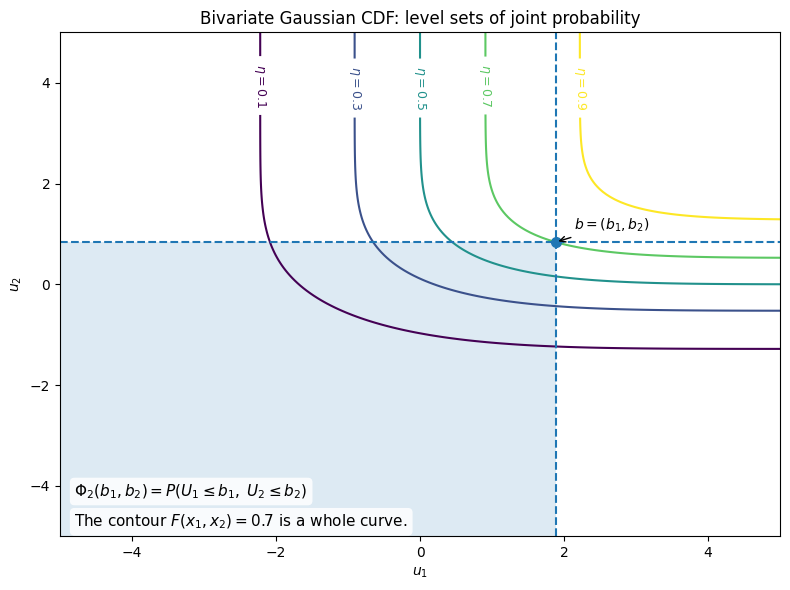

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 2D Gaussian parameters
mu = np.array([0.0, 0.0])
rho = 0.3
Sigma = np.array([[3.0, rho],
                  [rho, 1.0]])
rv = multivariate_normal(mean=mu, cov=Sigma)

# Grid for the bivariate CDF
low , up = -5, +5
x = np.linspace(low, up, 200)
y = np.linspace(low, up, 200)
X, Y = np.meshgrid(x, y)
Z = np.empty_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = rv.cdf([X[i, j], Y[i, j]])

eta = 0.70
levels = [0.1, 0.3, 0.5, eta, 0.9]

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(X, Y, Z, levels=levels)
ax.clabel(cs, inline=True, fontsize=9, fmt=lambda v: rf"$\eta={v:.1f}$")

# Pick one point directly from the eta contour
eta_index = levels.index(eta)
segments = cs.allsegs[eta_index]
seg = max(segments, key=lambda s: s.shape[0])  # longest contour segment
b = seg[len(seg) // 2]  # midpoint of the contour segment

# Draw the rectangle corresponding to F(b1,b2)=P(U1<=b1, U2<=b2)
ax.axvline(b[0], linestyle="--")
ax.axhline(b[1], linestyle="--")
ax.fill_between(x, low, b[1], where=(x <= b[0]), alpha=0.15)
ax.plot(b[0], b[1], marker="o", markersize=7)

ax.annotate(
    r"$b=(b_1,b_2)$",
    xy=(b[0], b[1]),
    xytext=(b[0] + 0.25, b[1] + 0.25),
    arrowprops=dict(arrowstyle="->")
)

ax.text(
    low+0.2, low+0.8,
    r"$\Phi_2(b_1,b_2)=P(U_1\leq b_1,\;U_2\leq b_2)$",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.3")
)

ax.text(
    low+0.2, low+0.2,
    r"The contour $F(x_1,x_2)=0.7$ is a whole curve.",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, boxstyle="round,pad=0.3")
)
bbox=dict(facecolor="white", edgecolor="black", alpha=0.85, boxstyle="round,pad=0.3")
ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_2$")
ax.set_title("Bivariate Gaussian CDF: level sets of joint probability")
ax.set_xlim(low , up)
ax.set_ylim(low , up)

plt.tight_layout()
plt.show()
